In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [6]:
DATA_ROOT = '../data'

In [7]:
results = pd.read_csv(f'{DATA_ROOT}/Pearsons_results.csv', index_col = 0, header = 0)

# Correlation and MSE plots

In [8]:
from plotting_functions import create_pearsons_violin

In [9]:
PEARSONS_training_data = pd.read_csv('../data/PEARSONS_results.csv')

In [10]:
genewise_correlations = pd.read_csv('./data/genewise_correlations', index_col=0)

In [11]:
genewise_correlations['LogMSE'] = np.log(genewise_correlations['MSE']+1)

In [12]:
np.sort(genewise_correlations[genewise_correlations['dataset'] == 'Train']['pearsons'])

array([-0.9987995 , -0.90427183, -0.82733209, ...,  0.96437079,
        0.96532573,  0.97125173])

In [13]:
np.sort(1 - results['train_loss'])

array([-0.93830931, -0.9336729 , -0.87022805, ...,  0.9595716 ,
        0.97724217,  0.99998087])

<Axes: >

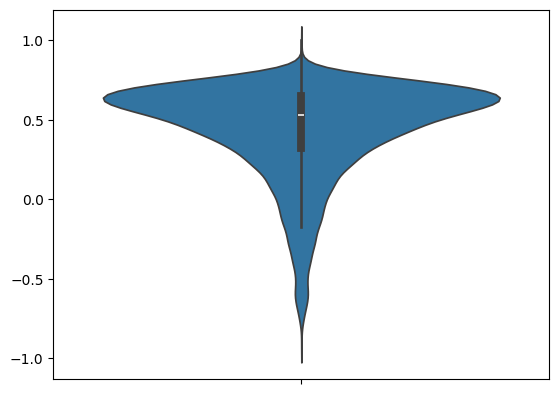

In [14]:
sns.violinplot(np.sort(1 - results['test_loss']))

<Axes: >

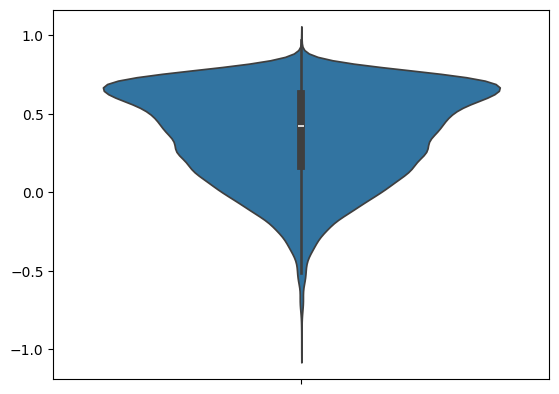

In [15]:
sns.violinplot(np.sort(genewise_correlations[genewise_correlations['dataset'] == 'Train']['pearsons']))

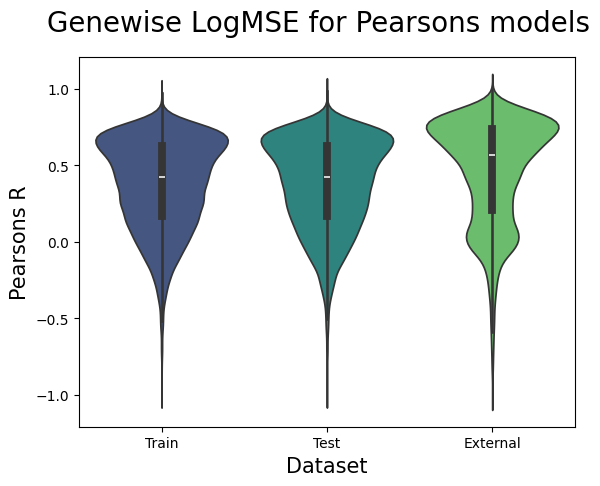

In [16]:
create_pearsons_violin(genewise_correlations, y_col='pearsons', title = 'Genewise LogMSE for Pearsons models', file_title = 'genewise_LogMSE_PEARSONS')

In [17]:
from_train_losses = results[['train_loss', 'test_loss']].melt()
from_train_losses.columns = ['dataset', 'value']

In [18]:
from_train_losses['value'] = 1 - from_train_losses['value']

In [19]:
from_train_losses

,dataset,value
0,train_loss,0.031068
1,train_loss,-0.174456
2,train_loss,-0.094459
3,train_loss,0.417640
4,train_loss,0.681664
...,...,...
32195,test_loss,-0.214892
32196,test_loss,0.581442
32197,test_loss,0.728245
32198,test_loss,0.761174


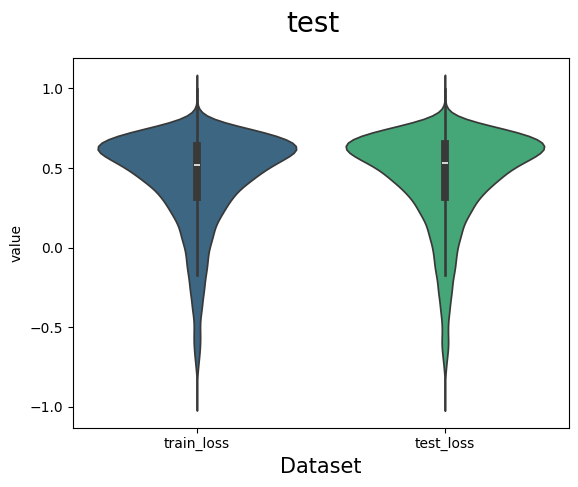

In [20]:
create_pearsons_violin(from_train_losses, y_col = 'value', title = 'test', file_title = 'TEMP')